# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [3]:
# untuk plot Q-Q
import scipy.stats as stats

In [4]:
df_california = pd.read_csv('california_dataset.csv')

In [5]:
from sklearn.model_selection import train_test_split

# splitting terlebih dahulu
X = df_california.drop(columns=['house_price'])
y = df_california['house_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Gabungkan jadi df_train untuk outlier handling
df_train = X_train.copy()
df_train['house_price'] = y_train

print(f'Shape train: {df_train.shape}')
print(f'Shape test : {X_test.shape}')

#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

Shape train: (16512, 9)
Shape test : (4128, 8)


### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

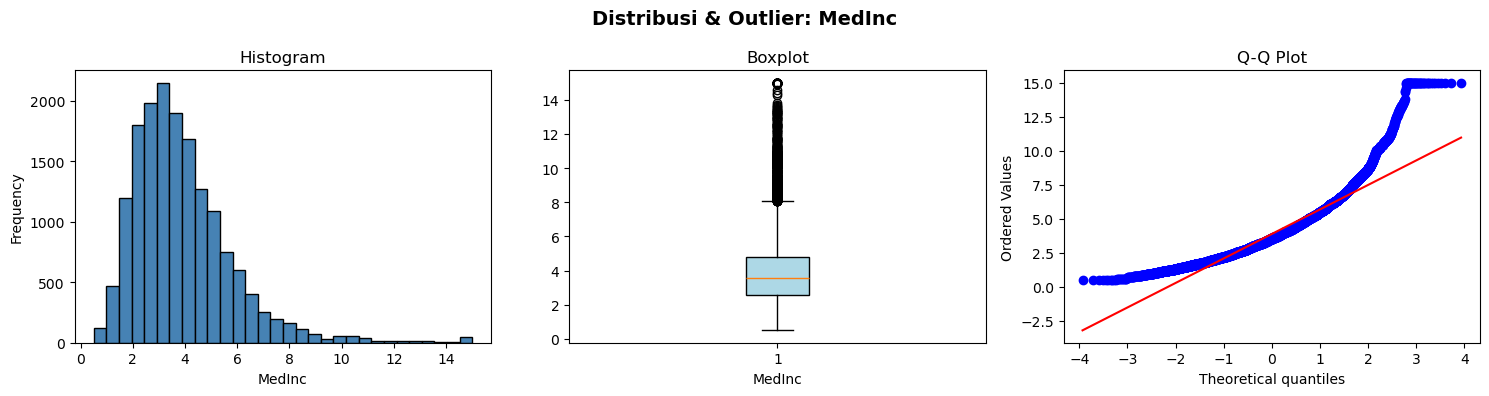

Statistik MedInc:
count    16512.000000
mean         3.880754
std          1.904294
min          0.499900
25%          2.566700
50%          3.545800
75%          4.773175
max         15.000100
Name: MedInc, dtype: float64
--------------------------------------------------


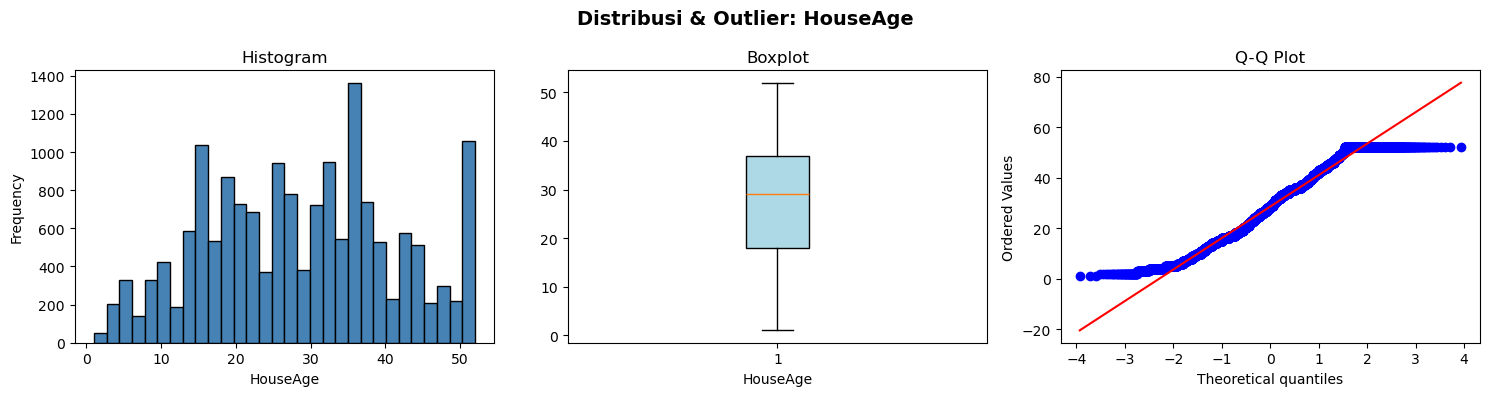

Statistik HouseAge:
count    16512.000000
mean        28.608285
std         12.602499
min          1.000000
25%         18.000000
50%         29.000000
75%         37.000000
max         52.000000
Name: HouseAge, dtype: float64
--------------------------------------------------


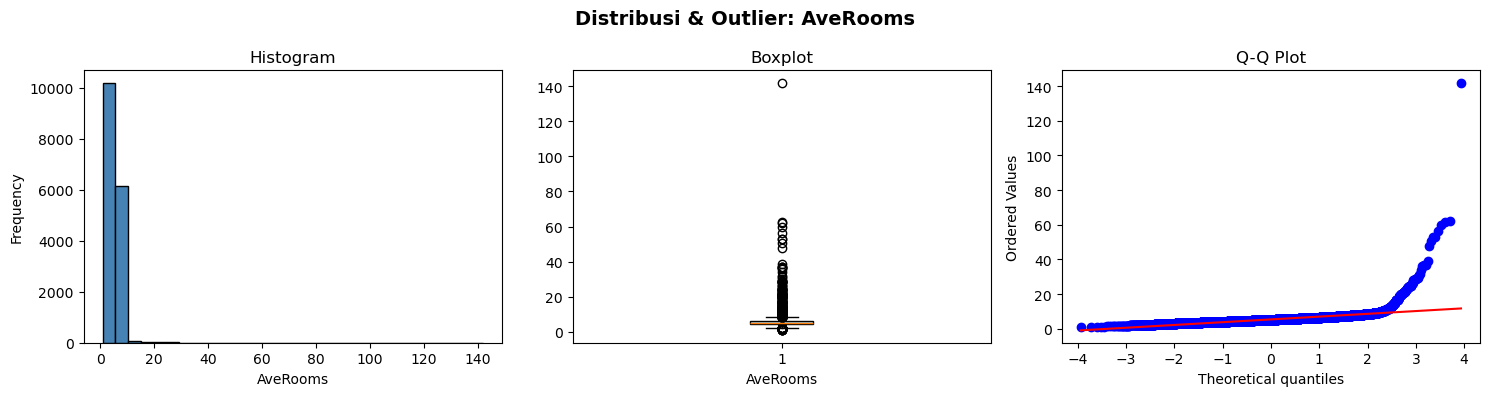

Statistik AveRooms:
count    16512.000000
mean         5.435235
std          2.387375
min          0.888889
25%          4.452055
50%          5.235874
75%          6.061037
max        141.909091
Name: AveRooms, dtype: float64
--------------------------------------------------


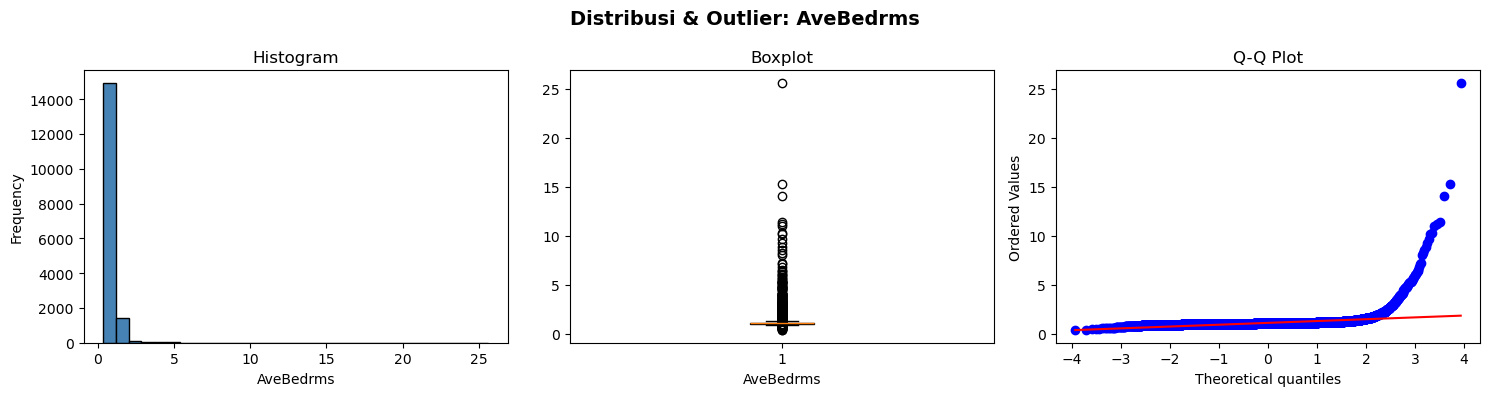

Statistik AveBedrms:
count    16512.000000
mean         1.096685
std          0.433215
min          0.333333
25%          1.006508
50%          1.049286
75%          1.100348
max         25.636364
Name: AveBedrms, dtype: float64
--------------------------------------------------


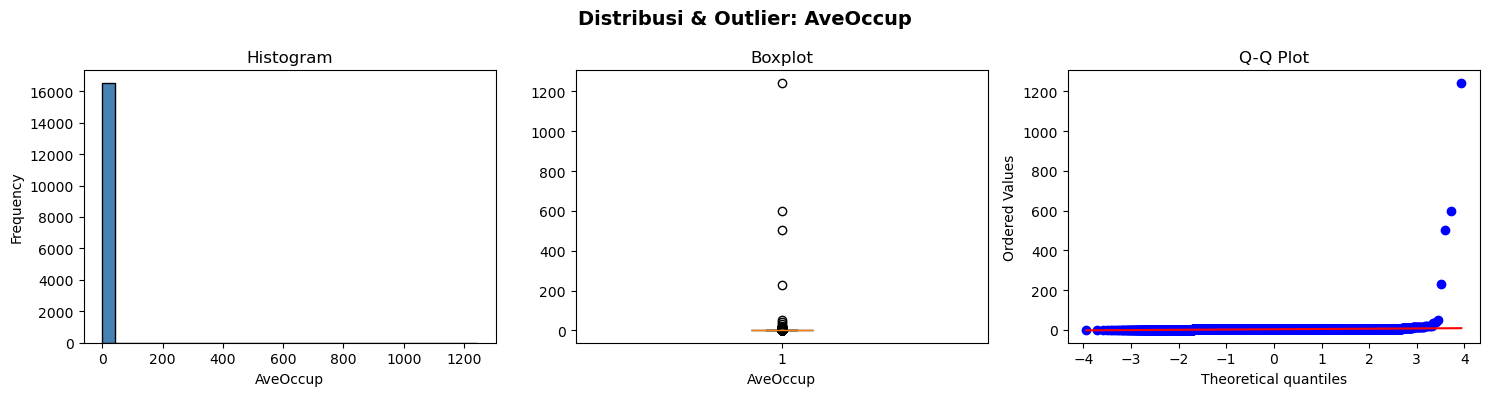

Statistik AveOccup:
count    16512.000000
mean         3.096961
std         11.578744
min          0.692308
25%          2.428799
50%          2.817240
75%          3.280000
max       1243.333333
Name: AveOccup, dtype: float64
--------------------------------------------------


In [6]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
# Daftar nama kolom yang ingin Anda cek

kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

for col in kolom_kolom:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Distribusi & Outlier: {col}', fontsize=14, fontweight='bold')
    
    # 1. Histogram
    axes[0].hist(df_train[col], bins=30, color='steelblue', edgecolor='black')
    axes[0].set_title('Histogram')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    
    # 2. Boxplot
    axes[1].boxplot(df_train[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[1].set_title('Boxplot')
    axes[1].set_xlabel(col)
    
    # 3. Q-Q Plot
    stats.probplot(df_train[col], dist='norm', plot=axes[2])
    axes[2].set_title('Q-Q Plot')
    
    plt.tight_layout()
    plt.show()
    print(f'Statistik {col}:')
    print(df_train[col].describe())
    print('-'*50)

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

In [8]:
### Assignment 1.b - Handling outlier kolom AveRooms dengan IQR

kolom_iqr = 'AveRooms'

# Hitung IQR
Q1 = df_train[kolom_iqr].quantile(0.25)
Q3 = df_train[kolom_iqr].quantile(0.75)
IQR = Q3 - Q1

# Tentukan batas bawah dan atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1         : {Q1:.4f}')
print(f'Q3         : {Q3:.4f}')
print(f'IQR        : {IQR:.4f}')
print(f'Lower bound: {lower_bound:.4f}')
print(f'Upper bound: {upper_bound:.4f}')

# Jumlah outlier sebelum handling
outlier_mask = (df_train[kolom_iqr] < lower_bound) | (df_train[kolom_iqr] > upper_bound)
print()
print(f'Jumlah outlier sebelum handling: {outlier_mask.sum()}')

# Capping (Winsorizing) - clip nilai di luar batas ke batas terdekat
df_train[kolom_iqr] = df_train[kolom_iqr].clip(lower=lower_bound, upper=upper_bound)

# Validasi setelah handling
outlier_after = (df_train[kolom_iqr] < lower_bound) | (df_train[kolom_iqr] > upper_bound)
print(f'Jumlah outlier setelah handling : {outlier_after.sum()}')

Q1         : 4.4521
Q3         : 6.0610
IQR        : 1.6090
Lower bound: 2.0386
Upper bound: 8.4745

Jumlah outlier sebelum handling: 410
Jumlah outlier setelah handling : 0


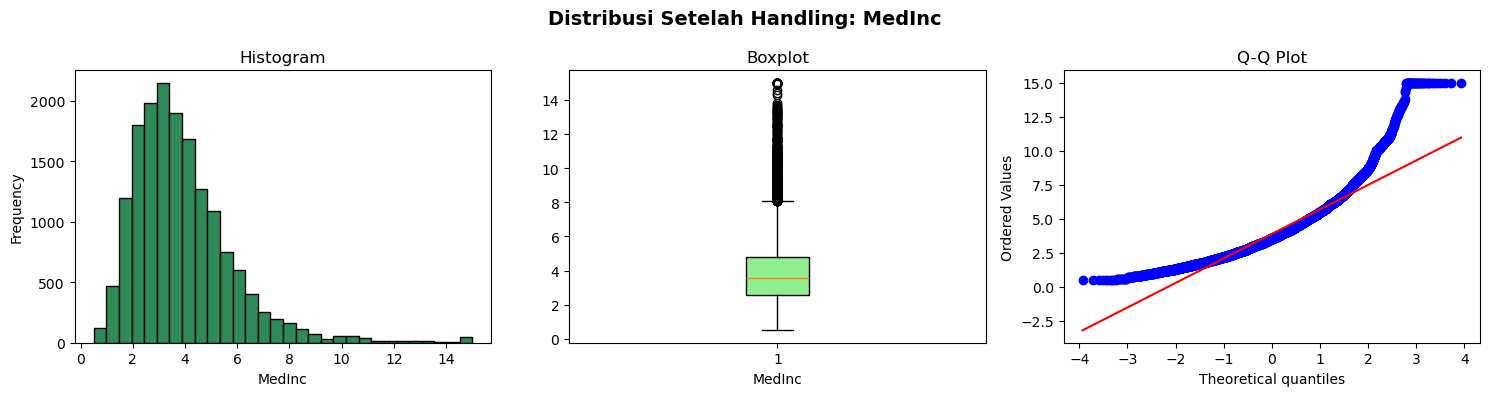

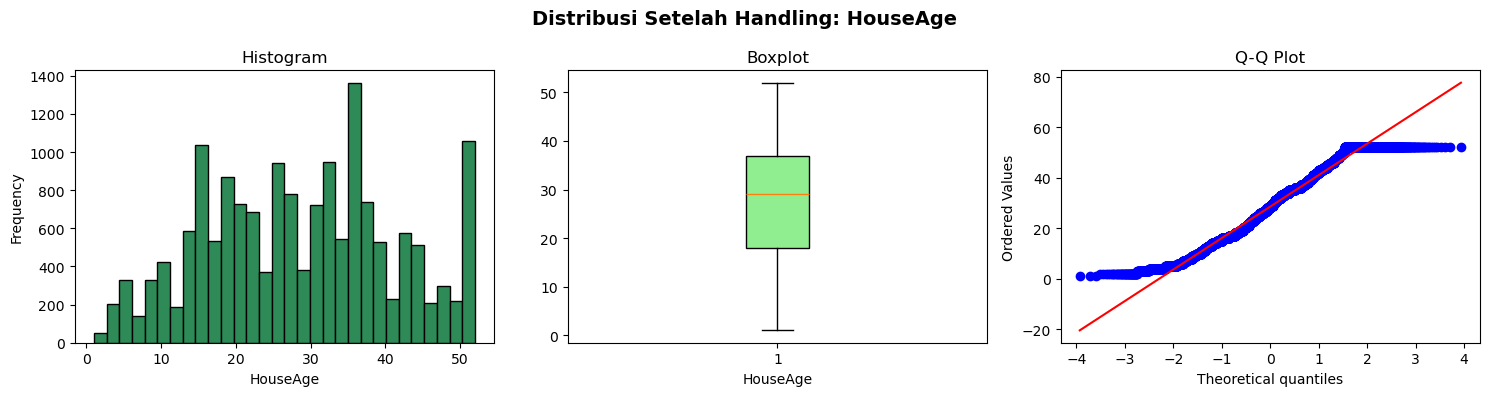

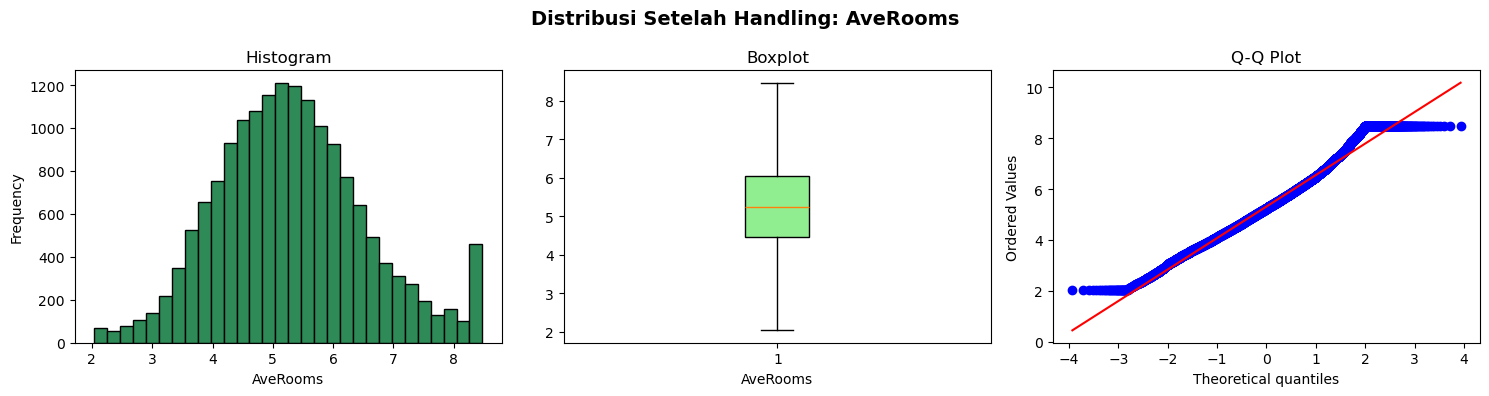

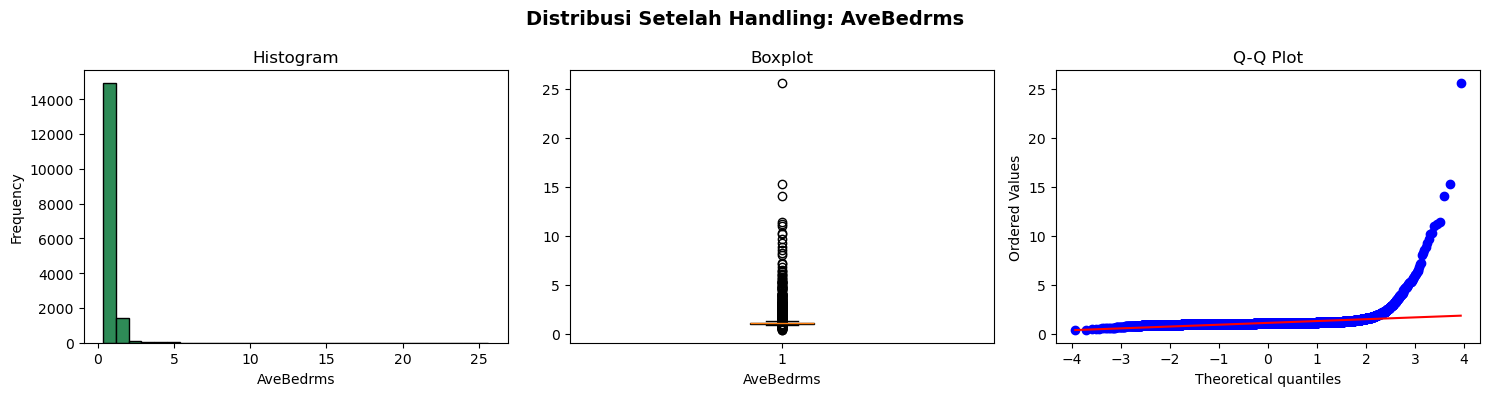

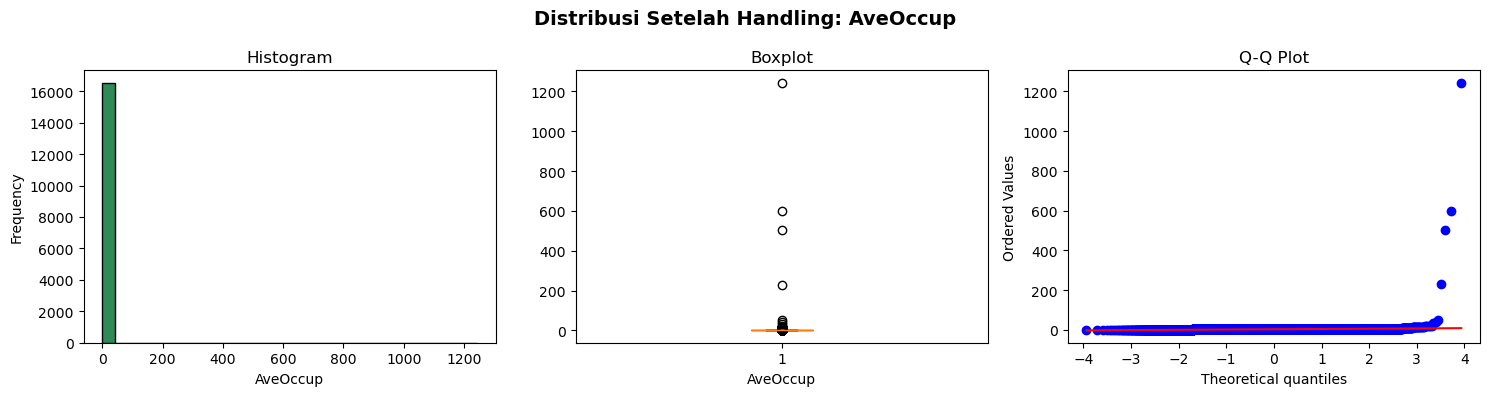

In [9]:
# Melakukan loop untuk mengecek distribusi tiap kolom SETELAH handling outlier AveRooms
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

for col in kolom_kolom:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Distribusi Setelah Handling: {col}', fontsize=14, fontweight='bold')

    axes[0].hist(df_train[col], bins=30, color='seagreen', edgecolor='black')
    axes[0].set_title('Histogram')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    axes[1].boxplot(df_train[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightgreen'))
    axes[1].set_title('Boxplot')
    axes[1].set_xlabel(col)

    stats.probplot(df_train[col], dist='norm', plot=axes[2])
    axes[2].set_title('Q-Q Plot')

    plt.tight_layout()
    plt.show()

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [10]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [11]:
from sklearn.model_selection import train_test_split

# Splitting terlebih dahulu
df_train_comp, df_test_comp = train_test_split(df_company, test_size=0.2, random_state=42)

print(f'Shape train: {df_train_comp.shape}')
print(f'Shape test : {df_test_comp.shape}')

#train : test = 80:20

Shape train: (537, 4)
Shape test : (135, 4)


## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [13]:
# Tulis jawaban missing value handling kolom Headquarters disini

# 1. Cek jenis missing value
# Nilai "-1" merupakan missing value tersembunyi (disguised missing value)
# karena Headquarters bertipe kategorik, nilai angka "-1" tidak relevan
print("=== Cek Missing Value Kolom Headquarters ===")
print(df_train_comp["Headquarters"].value_counts(dropna=False).head(10))

jumlah_missing = (df_train_comp["Headquarters"] == "-1").sum()
persen_missing = jumlah_missing / len(df_train_comp) * 100
print()
print(f"Jumlah missing value (-1): {jumlah_missing}")
print(f"Persentase missing value  : {persen_missing:.2f}%")

# 2. Keputusan drop atau tidak (syarat drop > 20%)
print()
print(f"Syarat drop: > 20% | Persentase: {persen_missing:.2f}%")
if persen_missing > 20:
    print("Keputusan: DROP kolom Headquarters")
    df_train_comp = df_train_comp.drop(columns=["Headquarters"])
else:
    print("Keputusan: TIDAK drop, lakukan handling")
    # 3. Tipe kategorik -> handling dengan MODUS
    df_train_comp["Headquarters"] = df_train_comp["Headquarters"].replace("-1", np.nan)
    modus_hq = df_train_comp["Headquarters"].mode()[0]
    print(f"Modus Headquarters: {modus_hq}")
    df_train_comp["Headquarters"] = df_train_comp["Headquarters"].fillna(modus_hq)
    print(f"Sisa missing value: {df_train_comp['Headquarters'].isnull().sum()}")
    print(df_train_comp["Headquarters"].value_counts().head(5))

=== Cek Missing Value Kolom Headquarters ===
Headquarters
New York, NY                 29
San Francisco, CA            28
-1                           24
Chicago, IL                  20
Boston, MA                   13
Mc Lean, VA                  12
Westminster, CO              10
Reston, VA                    9
Cambridge, MA                 8
Cambridge, United Kingdom     8
Name: count, dtype: int64

Jumlah missing value (-1): 24
Persentase missing value  : 4.47%

Syarat drop: > 20% | Persentase: 4.47%
Keputusan: TIDAK drop, lakukan handling
Modus Headquarters: New York, NY
Sisa missing value: 0
Headquarters
New York, NY         53
San Francisco, CA    28
Chicago, IL          20
Boston, MA           13
Mc Lean, VA          12
Name: count, dtype: int64


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [14]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
# Splitting terlebih dahulu
df_train_churn, df_test_churn = train_test_split(df_churn, test_size=0.2, random_state=42)

print(f'Shape train: {df_train_churn.shape}')
print(f'Shape test : {df_test_churn.shape}')

Shape train: (5634, 21)
Shape test : (1409, 21)


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [17]:
# Tulis jawaban
from sklearn.preprocessing import LabelEncoder

# 1. Kolom yang akan di-encode
kolom_encode = ["StreamingMovies", "StreamingTV", "TechSupport",
                "DeviceProtection", "OnlineBackup", "OnlineSecurity", "MultipleLines"]

# 2. Ganti nilai tidak sesuai menjadi No
for col in kolom_encode:
    df_train_churn[col] = df_train_churn[col].replace({
        "No internet service": "No",
        "No phone service": "No"
    })

# Validasi dengan value_counts
print("=== Validasi setelah replace ===")
for col in kolom_encode:
    print()
    print(f"{col}:")
    print(df_train_churn[col].value_counts())

=== Validasi setelah replace ===

StreamingMovies:
StreamingMovies
No     3437
Yes    2197
Name: count, dtype: int64

StreamingTV:
StreamingTV
No     3453
Yes    2181
Name: count, dtype: int64

TechSupport:
TechSupport
No     4005
Yes    1629
Name: count, dtype: int64

DeviceProtection:
DeviceProtection
No     3703
Yes    1931
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No     3662
Yes    1972
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No     4024
Yes    1610
Name: count, dtype: int64

MultipleLines:
MultipleLines
No     3237
Yes    2397
Name: count, dtype: int64


In [18]:
# 3. Label Encoding: No -> 0, Yes -> 1
le = LabelEncoder()

for col in kolom_encode:
    df_train_churn[col] = le.fit_transform(df_train_churn[col])

print("=== Hasil Label Encoding ===")
print(df_train_churn[kolom_encode].head(10))
print()
print("Unique values setelah encoding:")
for col in kolom_encode:
    print(f"{col}: {sorted(df_train_churn[col].unique())}")

=== Hasil Label Encoding ===
      StreamingMovies  StreamingTV  TechSupport  DeviceProtection  \
2142                1            0            0                 1   
1623                1            1            0                 0   
6074                0            0            0                 0   
1362                0            0            0                 0   
6754                0            0            1                 0   
1212                0            0            0                 0   
2722                0            0            0                 0   
4006                0            0            0                 0   
6791                0            1            0                 1   
5466                0            0            0                 0   

      OnlineBackup  OnlineSecurity  MultipleLines  
2142             0               1              0  
1623             1               0              1  
6074             0               0              0  
136

In [19]:
# Konfirmasi mapping: No = 0, Yes = 1
print("Statistik kolom setelah Label Encoding:")
print(df_train_churn[kolom_encode].describe())

Statistik kolom setelah Label Encoding:
       StreamingMovies  StreamingTV  TechSupport  DeviceProtection  \
count      5634.000000  5634.000000  5634.000000       5634.000000   
mean          0.389954     0.387114     0.289137          0.342741   
std           0.487783     0.487133     0.453402          0.474668   
min           0.000000     0.000000     0.000000          0.000000   
25%           0.000000     0.000000     0.000000          0.000000   
50%           0.000000     0.000000     0.000000          0.000000   
75%           1.000000     1.000000     1.000000          1.000000   
max           1.000000     1.000000     1.000000          1.000000   

       OnlineBackup  OnlineSecurity  MultipleLines  
count   5634.000000     5634.000000    5634.000000  
mean       0.350018        0.285765       0.425453  
std        0.477018        0.451818       0.494455  
min        0.000000        0.000000       0.000000  
25%        0.000000        0.000000       0.000000  
50%        

## Selesai :)